# 데이터 정제

In [1]:
import sys
import os
# Add the project root directory to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from scripts.utils import get_time_series, get_timestamp_index, cleaning_data, feature_engineering

In [2]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import logging
from datetime import datetime
random.seed(42)         # Python built-in random module
np.random.seed(42)

In [3]:
# 로깅 설정
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(f"regression_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"),
        logging.StreamHandler()  # 콘솔에도 출력
    ]
)
logger = logging.getLogger(__name__)

# 데이터 로드
logger.info("데이터 로드 시작")

2025-04-08 15:29:48,299 - INFO - 데이터 로드 시작


In [4]:
raw_data = pd.read_csv('../raw_data_20250403.csv')

In [5]:
data = get_timestamp_index(raw_data)

In [6]:
seoul = cleaning_data(data,'Seoul')

/Volumes/SUNSE/projects/building-ml-pipeline/scripts/utils.py:70: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_resampled[numeric_time_features] = data_resampled[numeric_time_features].interpolate(method='time')
/Volumes/SUNSE/projects/building-ml-pipeline/scripts/utils.py:71: FutureWarning: DataFrame.interpolate with method=bfill is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_resampled[categorical_date_features] = data_resampled[categorical_date_features].interpolate(method='bfill')
/Volumes/SUNSE/projects/building-ml-pipeline/scripts/utils.py:74: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

# 피처 엔지니어링

In [8]:
seoul_feature = feature_engineering(seoul)


In [9]:
seoul_feature.columns

Index(['PTY', 'REH', 'RN1', 'T1H', 'WSD', 'delay_hours', 'base_date', 'year',
       'month', 'day', 'day_of_week', 'is_holiday', 'hour', 'nx', 'ny',
       'admin_district_code', 'sin_hour', 'cos_hour', 'is_weekend',
       'day_of_week_encoded', 'PTY_lag1', 'PTY_lag2', 'delay_hours_lag1',
       'delay_hours_lag2'],
      dtype='object')

In [10]:
seoul_feature.isnull().sum()

PTY                    0
REH                    0
RN1                    0
T1H                    0
WSD                    0
delay_hours            0
base_date              0
year                   0
month                  0
day                    0
day_of_week            0
is_holiday             0
hour                   0
nx                     0
ny                     0
admin_district_code    0
sin_hour               0
cos_hour               0
is_weekend             0
day_of_week_encoded    0
PTY_lag1               1
PTY_lag2               2
delay_hours_lag1       1
delay_hours_lag2       2
dtype: int64

/var/folders/8m/jbl92pvn45zg5k2bbfx4ff840000gn/T/ipykernel_87829/446306664.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seoul_feature = seoul_feature.fillna(method='bfill')


In [12]:
seoul_feature.head()

,PTY,REH,RN1,T1H,WSD,delay_hours,base_date,year,month,day,...,ny,admin_district_code,sin_hour,cos_hour,is_weekend,day_of_week_encoded,PTY_lag1,PTY_lag2,delay_hours_lag1,delay_hours_lag2
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-03-19 04:00:00,0.0,55.0,0.0,-0.4,0.4,0.449816,2025-03-19,2025.0,3.0,19.0,...,125.0,1.171065e+09,0.866025,5.000000e-01,0,6,0.0,0.0,0.449816,0.449816
2025-03-19 05:00:00,0.0,55.0,0.0,-0.5,0.8,0.680286,2025-03-19,2025.0,3.0,19.0,...,125.0,1.171065e+09,0.965926,2.588190e-01,0,6,0.0,0.0,0.449816,0.449816
2025-03-19 06:00:00,0.0,60.0,0.0,-1.2,0.7,0.592798,2025-03-19,2025.0,3.0,19.0,...,125.0,1.171065e+09,1.000000,6.123234e-17,0,6,0.0,0.0,0.680286,0.449816
2025-03-19 07:00:00,0.0,59.0,0.0,-0.6,1.1,0.539463,2025-03-19,2025.0,3.0,19.0,...,125.0,1.171065e+09,0.965926,-2.588190e-01,0,6,0.0,0.0,0.592798,0.680286
2025-03-19 08:00:00,0.0,55.0,0.0,0.6,1.2,0.000000,2025-03-19,2025.0,3.0,19.0,...,125.0,1.171065e+09,0.866025,-5.000000e-01,0,6,0.0,0.0,0.539463,0.592798


In [13]:
seoul_feature['delay_hours'] = np.log1p(seoul_feature['delay_hours'])

In [14]:
corr_test = ['PTY', 'REH', 'RN1', 'T1H', 'WSD', 'delay_hours', 'hour',
        'sin_hour', 'cos_hour', 'is_weekend',
       'day_of_week_encoded','delay_hours_lag1', 'delay_hours_lag2','PTY_lag1', 'PTY_lag2',]

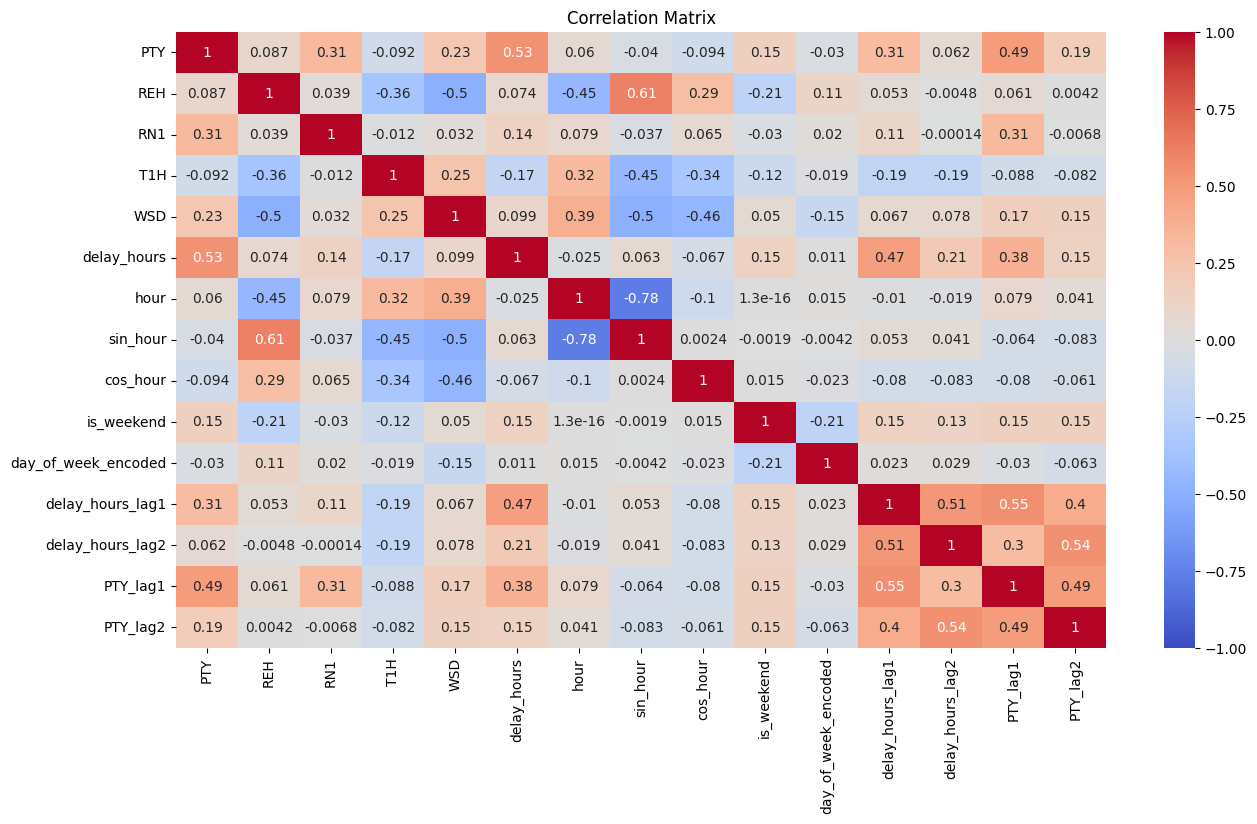

2025-04-08 15:29:48,691 - INFO - delay_hours와 피처 간 상관계수:
2025-04-08 15:29:48,692 - INFO - delay_hours            1.000000
PTY                    0.532513
delay_hours_lag1       0.471924
PTY_lag1               0.377610
delay_hours_lag2       0.214064
is_weekend             0.148045
PTY_lag2               0.147963
RN1                    0.144008
WSD                    0.099241
REH                    0.074044
sin_hour               0.063057
day_of_week_encoded    0.010523
hour                  -0.025038
cos_hour              -0.066625
T1H                   -0.174866
Name: delay_hours, dtype: float64


In [15]:
plt.figure(figsize=(15, 8))
correlation_matrix = seoul_feature[corr_test].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

# delay_hours와 피처 간 상관계수
logger.info("delay_hours와 피처 간 상관계수:")
logger.info(correlation_matrix['delay_hours'].sort_values(ascending=False))